# Class 4: Vulnerability

## GIS Vulnerability & Risk Assessment Course

**Objective:** Understand how to combine Potential Impact and Adaptive Capacity into a single Vulnerability score using a lookup matrix.

## What is Vulnerability?

Vulnerability describes how susceptible something is to harm when exposed to a hazard.

**Key Formula:**
```
Vulnerability = Potential Impact × (1 / Adaptive Capacity)
```

Or more simply: **A location is vulnerable when:**
1. The potential impact of a hazard is HIGH, AND
2. The adaptive capacity (ability to cope, prepare, recover) is LOW

**Examples:**
- A flood-prone neighborhood with poor drainage and low-income residents = HIGH vulnerability
- A flood-prone neighborhood with excellent levees and well-resourced residents = LOWER vulnerability
- An earthquake-prone area with no building codes = HIGH vulnerability
- An earthquake-prone area with strict building codes = LOWER vulnerability

**In this class:** We'll use a simple lookup matrix to combine Potential Impact and Adaptive Capacity scores into a Vulnerability score.

In [4]:
!pip install geopandas fiona shapely pyproj requests folium seaborn contextily --quiet
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries loaded successfully!


## Step 1: Mount Your Google Drive

We'll store all data in Google Drive so you can access it anytime.

In [ ]:
# === ENVIRONMENT SETUP ===
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/MSER_510_VULNERABILTY'
    print("Google Drive connected!")
except Exception:
    BASE_DIR = './'
    print("Running locally.")

DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GeoPackage file paths for chained loading
INPUT_GPKG = os.path.join(DATA_DIR, 'class_3_adaptive_capacity.gpkg')  # Load from Class 3
OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_4_vulnerability.gpkg')  # Save to Class 4
CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')  # Fallback for base layers

print(f"  Base directory: {BASE_DIR}")
print(f"  Data directory: {DATA_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")

## Step 2: Understanding the Vulnerability Scoring Matrix

The **Vulnerability Scoring Matrix** is a simple lookup table that combines two factors:

| | **Potential Impact: Low (1)** | **Medium (2)** | **High (3)** |
|---|---|---|---|
| **Adaptive Capacity: Low (1)** | Medium (2) | High (3) | High (3) |
| **Adaptive Capacity: Medium (2)** | Low (1) | Medium (2) | High (3) |
| **Adaptive Capacity: High (3)** | Low (1) | Low (1) | Medium (2) |

**How to read it:**
1. Find your **Adaptive Capacity** value (1, 2, or 3) on the LEFT side
2. Find your **Potential Impact** value (1, 2, or 3) on the TOP
3. Where they intersect = your **Vulnerability** score

**Key insights:**
- **High Adaptive Capacity + Low Potential Impact = LOW Vulnerability** (best case!)
- **Low Adaptive Capacity + High Potential Impact = HIGH Vulnerability** (worst case)
- Adaptive Capacity matters! Even if impact is high, good preparedness reduces vulnerability.

### Visual Guide to the Matrix

Below is a color-coded version. **Dark cells = high vulnerability; light cells = low vulnerability.**

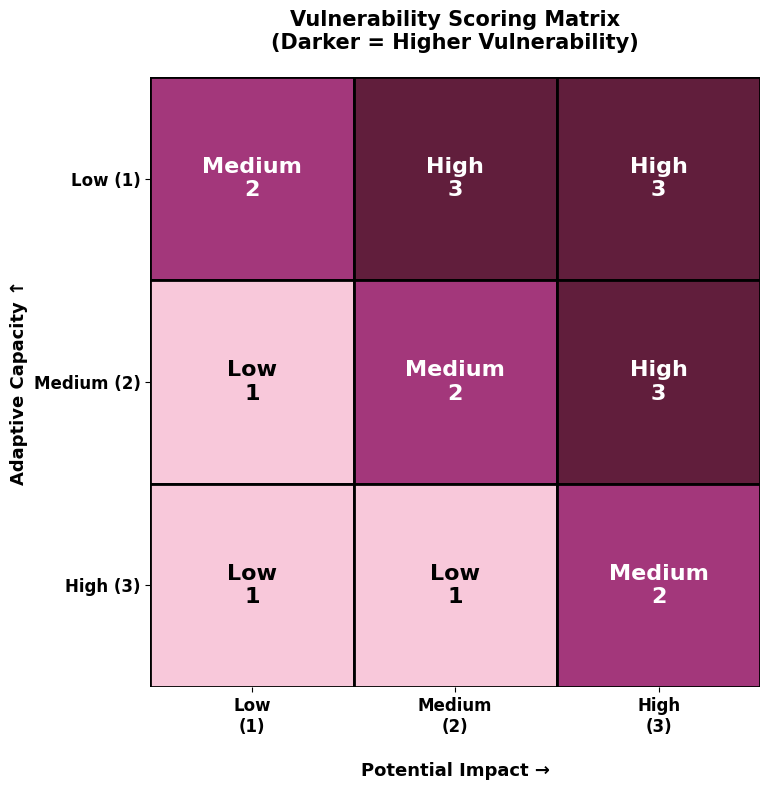

✓ Matrix visualization complete!


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Create the vulnerability matrix
# Format: matrix[adaptive_capacity_row, potential_impact_column]
# Where 0=index, 1=index, 2=index for values 1, 2, 3
vuln_matrix = np.array([
    [2, 3, 3],  # Row 0: Adaptive Capacity = Low (1)
    [1, 2, 3],  # Row 1: Adaptive Capacity = Medium (2)
    [1, 1, 2]   # Row 2: Adaptive Capacity = High (3)
])

# Color mapping using official symbology
# Vulnerability: 1 (Low)=#F8C8DA, 2 (Medium)=#A3377B, 3 (High)=#611E3C
colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}
text_colors = {1: 'black', 2: 'white', 3: 'white'}
labels = {1: 'Low\n1', 2: 'Medium\n2', 3: 'High\n3'}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the matrix cells
for i in range(3):
    for j in range(3):
        val = vuln_matrix[i, j]
        # Draw rectangle
        ax.add_patch(plt.Rectangle((j, 2-i), 1, 1, facecolor=colors[val], edgecolor='black', linewidth=2))
        # Add text label
        ax.text(j+0.5, 2-i+0.5, labels[val], ha='center', va='center',
                fontsize=16, fontweight='bold', color=text_colors[val])

# Set axis limits and properties
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')

# Set tick labels
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['Low\n(1)', 'Medium\n(2)', 'High\n(3)'], fontsize=12, fontweight='bold')
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['High (3)', 'Medium (2)', 'Low (1)'], fontsize=12, fontweight='bold')

# Add axis labels
ax.set_xlabel('\nPotential Impact →', fontsize=13, fontweight='bold')
ax.set_ylabel('Adaptive Capacity ↑', fontsize=13, fontweight='bold')

# Add title
ax.set_title('Vulnerability Scoring Matrix\n(Darker = Higher Vulnerability)',
             fontsize=15, fontweight='bold', pad=20)

# Remove spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ Matrix visualization complete!"
)

### Example: How to Read the Matrix

**Example 1: Area with Medium Adaptive Capacity & High Potential Impact**
- Adaptive Capacity = 2 (Medium) → Look at the MIDDLE row
- Potential Impact = 3 (High) → Look at the RIGHT column
- Intersection = **3 (High Vulnerability)**
- Interpretation: Even though the area has some adaptive capacity, the high impact of the hazard creates high overall vulnerability.

**Example 2: Area with High Adaptive Capacity & Low Potential Impact**
- Adaptive Capacity = 3 (High) → Look at the BOTTOM row
- Potential Impact = 1 (Low) → Look at the LEFT column
- Intersection = **1 (Low Vulnerability)**
- Interpretation: The area has good adaptive capacity AND the impact is limited, so vulnerability is low.

**Example 3: Area with Low Adaptive Capacity & Low Potential Impact**
- Adaptive Capacity = 1 (Low) → Look at the TOP row
- Potential Impact = 1 (Low) → Look at the LEFT column
- Intersection = **2 (Medium Vulnerability)**
- Interpretation: Even though the impact is low, the poor adaptive capacity means moderate vulnerability. This area still needs attention!

## Step 3: Load Your Parcels Data

We'll load parcels that already have **Potential Impact** and **Adaptive Capacity** scores from previous classes.

In [8]:
# Define the path to the GeoPackage (from Class 3)
gpkg_path = INPUT_GPKG

# Check if GeoPackage exists
if os.path.exists(gpkg_path):
    # List all layers in the GeoPackage
    import fiona
    layers = fiona.listlayers(gpkg_path)
    print(f"Layers in GeoPackage: {layers}")

    # Load the parcels layer
    parcels = gpd.read_file(gpkg_path, layer='parcels')
    print(f"\n✓ Successfully loaded parcels from Class 3!")
    print(f"Number of parcels: {len(parcels)}")
    print(f"\nColumns: {list(parcels.columns)}")
    print(f"\nFirst few rows:")
    print(parcels.head())
else:
    print(f"⚠ GeoPackage not found: {gpkg_path}")
    print("Attempting fallback from CLASS0_GPKG...")
    try:
        parcels = gpd.read_file(CLASS0_GPKG, layer='parcels')
        print(f"✓ Successfully loaded from fallback")
    except Exception as e:
        print(f"✗ Fallback also failed: {e}")

Layers in GeoPackage: ['flood_zones_100yr', 'study_area', 'flood_zones', 'buildings', 'parcels']

✓ Successfully loaded parcels from Class 3!
Number of parcels: 16078

Columns: ['objectid', 'parno', 'altparno', 'ownname', 'improvval', 'landval', 'parval', 'mailadd', 'munit', 'mcity', 'mstate', 'mzip', 'siteadd', 'sunit', 'scity', 'gisacres', 'struct', 'multistruc', 'saledate', 'saledatetx', 'legdecfull', 'parusecode', 'parusedesc', 'parusecd2', 'parusedsc2', 'parvaltype', 'owntype', 'recareano', 'recareatx', 'revisedate', 'sourceref', 'sourcedate', 'sourcedatx', 'subdivisio', 'nparno', 'cntyname', 'cntyfips', 'stfips', 'stcntyfips', 'gnisid', 'sourceagnt', 'transfdate', 'maddpref', 'maddrno', 'maddstname', 'maddstr', 'maddstsuf', 'maddsttyp', 'ownfrst', 'ownlast', 'revdatetx', 'reviseyear', 'saddno', 'saddpref', 'saddstname', 'saddstr', 'saddstsuf', 'saddsttyp', 'sstate', 'stname', 'subowntype', 'subsurfown', 'szip', 'structno', 'structyear', 'ownname2', 'presentval', 'mapref', 'st_are

### Verify Required Columns

We need **adaptive_capacity** and **potential_impact** columns to calculate vulnerability.

In [9]:
# Check if required columns exist
required_cols = ['adaptive_capacity_a1', 'adaptive_capacity_a2', 'potential_impact_a1', 'potential_impact_a2']
missing_cols = [col for col in required_cols if col not in parcels.columns]

if missing_cols:
    print(f"⚠ Missing columns: {missing_cols}")
    print("\nAvailable columns:")
    print(parcels.columns.tolist())
else:
    print("✓ All required columns present!")
    for col in required_cols:
        print(f"  {col}: {sorted(parcels[col].unique())}")

## Step 4: Calculate Vulnerability Scores (Separately for Each Asset Group)

We apply the vulnerability matrix **separately** for Asset 1 and Asset 2.
Each asset group uses its own `potential_impact` and `adaptive_capacity` scores.

This produces: `vulnerability_a1` and `vulnerability_a2`.

In [10]:
# Create the vulnerability matrix as a dictionary
# Key: (adaptive_capacity, potential_impact) → Value: vulnerability_score
vuln_lookup_matrix = {
    (1, 1): 2,  # Low AC, Low PI → Medium vulnerability
    (1, 2): 3,  # Low AC, Medium PI → High vulnerability
    (1, 3): 3,  # Low AC, High PI → High vulnerability
    (2, 1): 1,  # Medium AC, Low PI → Low vulnerability
    (2, 2): 2,  # Medium AC, Medium PI → Medium vulnerability
    (2, 3): 3,  # Medium AC, High PI → High vulnerability
    (3, 1): 1,  # High AC, Low PI → Low vulnerability
    (3, 2): 1,  # High AC, Medium PI → Low vulnerability
    (3, 3): 2,  # High AC, High PI → Medium vulnerability
}

print("Vulnerability Lookup Matrix:")
print("-" * 50)
for key, value in sorted(vuln_lookup_matrix.items()):
    ac, pi = key
    ac_label = ['Low', 'Medium', 'High'][ac - 1]
    pi_label = ['Low', 'Medium', 'High'][pi - 1]
    v_label = ['Low', 'Medium', 'High'][value - 1]
    print(f"AC={ac} ({ac_label:6s}), PI={pi} ({pi_label:6s}) → Vulnerability={value} ({v_label})")

Vulnerability Lookup Matrix:
--------------------------------------------------
AC=1 (Low   ), PI=1 (Low   ) → Vulnerability=2 (Medium)
AC=1 (Low   ), PI=2 (Medium) → Vulnerability=3 (High)
AC=1 (Low   ), PI=3 (High  ) → Vulnerability=3 (High)
AC=2 (Medium), PI=1 (Low   ) → Vulnerability=1 (Low)
AC=2 (Medium), PI=2 (Medium) → Vulnerability=2 (Medium)
AC=2 (Medium), PI=3 (High  ) → Vulnerability=3 (High)
AC=3 (High  ), PI=1 (Low   ) → Vulnerability=1 (Low)
AC=3 (High  ), PI=2 (Medium) → Vulnerability=1 (Low)
AC=3 (High  ), PI=3 (High  ) → Vulnerability=2 (Medium)


### Apply the Matrix to Your Data

We'll create a new column called **vulnerability** by looking up each parcel's (adaptive_capacity, potential_impact) pair in the matrix.

In [11]:
# Apply the vulnerability matrix separately for each asset group
parcels['vulnerability_a1'] = parcels.apply(
    lambda row: vuln_lookup_matrix.get((row['adaptive_capacity_a1'], row['potential_impact_a1']), 0),
    axis=1
)
parcels['vulnerability_a2'] = parcels.apply(
    lambda row: vuln_lookup_matrix.get((row['adaptive_capacity_a2'], row['potential_impact_a2']), 0),
    axis=1
)

print("Vulnerability scores calculated for both asset groups!")
for col, label in [('vulnerability_a1', 'Asset 1'), ('vulnerability_a2', 'Asset 2')]:
    asset_flag = 'is_asset_1' if 'a1' in col else 'is_asset_2'
    in_group = parcels[parcels[asset_flag] == 1]
    print(f"\n{label} ({len(in_group):,} parcels):")
    for score in sorted(in_group[col].unique()):
        if score == 0:
            continue
        count = (in_group[col] == score).sum()
        pct = 100 * count / len(in_group)
        vlabel = {1: 'Low', 2: 'Medium', 3: 'High'}.get(score, '?')
        print(f"  {vlabel} ({score}): {count:,} parcels ({pct:.1f}%)")

## Step 4b: Vulnerability Results Matrix with Cross-Tabulation

Now that we've calculated vulnerability scores for each parcel, let's visualize the **results matrix**.

This matrix shows:
- **Rows**: Adaptive Capacity (AC) levels: Low (1), Medium (2), High (3)
- **Columns**: Potential Impact (PI) levels: Low (1), Medium (2), High (3)
- **Cell Contents**: For each AC-PI combination in your actual data:
  - The vulnerability score label (Low/Medium/High + number)
  - Count of parcels with that AC-PI combination
  - Total parcel land value
  - Total building/improvement value

**Color Key:**
- Light pink background = Low vulnerability (1)
- Magenta/purple background = Medium vulnerability (2)  
- Dark burgundy background = High vulnerability (3)

This helps you see not just how parcels are distributed by their characteristics, but also the economic impact and concentration of risk in each combination.

In [18]:
# Helper function to format dollar values
def format_currency(value):
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    elif value >= 1_000:
        return f'${value / 1_000:.1f}K'
    else:
        return f'${int(value)}'

vuln_lookup_matrix = {
    (1, 1): 2, (1, 2): 3, (1, 3): 3,
    (2, 1): 1, (2, 2): 2, (2, 3): 3,
    (3, 1): 1, (3, 2): 1, (3, 3): 2,
}

vuln_labels = {1: 'Low', 2: 'Medium', 3: 'High'}
colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}
text_colors = {1: 'black', 2: 'white', 3: 'white'}

# Ensure structure_value exists and is clamped
if 'structure_value' not in parcels.columns:
    parcels['structure_value'] = (parcels['parval'] - parcels['landval']).clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(28, 11))

for ax, ac_col, pi_col, v_col, label in [
    (axes[0], 'adaptive_capacity_a1', 'potential_impact_a1', 'vulnerability_a1', 'Asset 1'),
    (axes[1], 'adaptive_capacity_a2', 'potential_impact_a2', 'vulnerability_a2', 'Asset 2'),
]:
    asset_flag = 'is_asset_1' if 'a1' in ac_col else 'is_asset_2'
    subset_all = parcels[parcels[asset_flag] == 1]
    
    for i, ac in enumerate([1, 2, 3]):
        for j, pi in enumerate([1, 2, 3]):
            mask = (subset_all[ac_col] == ac) & (subset_all[pi_col] == pi)
            subset = subset_all[mask]
            count = len(subset)
            parval_sum = subset['parval'].sum() if 'parval' in subset.columns else 0
            struct_sum = subset['structure_value'].sum()
            vuln_score = vuln_lookup_matrix.get((ac, pi), 0)
            bg_color = colors.get(vuln_score, '#FFFFFF')
            tc = text_colors.get(vuln_score, 'black')
            cell_y = 2 - i
            ax.add_patch(plt.Rectangle((j, cell_y), 1, 1, facecolor=bg_color, edgecolor='black', linewidth=2))
            cell_text = f'{vuln_labels.get(vuln_score, "?")} ({vuln_score})\n{count} parcels\n{format_currency(parval_sum)} parcel val\n{format_currency(struct_sum)} bldg val'
            ax.text(j + 0.5, cell_y + 0.5, cell_text, ha='center', va='center',
                    fontsize=9, fontweight='bold', color=tc)
    
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.set_xticks([0.5, 1.5, 2.5])
    ax.set_xticklabels(['PI: Low (1)', 'PI: Medium (2)', 'PI: High (3)'], fontsize=11, fontweight='bold')
    ax.set_yticks([0.5, 1.5, 2.5])
    ax.set_yticklabels(['AC: Low (1)', 'AC: Medium (2)', 'AC: High (3)'], fontsize=11, fontweight='bold')
    ax.set_xlabel('\nPotential Impact (PI)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Adaptive Capacity (AC)', fontsize=12, fontweight='bold')
    ax.set_title(f'Vulnerability Results Matrix: {label}', fontsize=14, fontweight='bold', pad=20)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()
print('✓ Vulnerability Results Matrix visualization complete!')

## Step 5: Analyze Vulnerability Results

Let's understand the distribution of vulnerability across your parcels.

In [13]:
# Vulnerability distribution per asset group
print("=" * 60)
print("VULNERABILITY DISTRIBUTION")
print("=" * 60)

vuln_labels = {1: 'Low', 2: 'Medium', 3: 'High'}

for col, label in [('vulnerability_a1', 'Asset 1'), ('vulnerability_a2', 'Asset 2')]:
    asset_flag = 'is_asset_1' if 'a1' in col else 'is_asset_2'
    in_group = parcels[parcels[asset_flag] == 1]
    print(f"\n{label} ({len(in_group):,} parcels):")
    for v in [1, 2, 3]:
        count = (in_group[col] == v).sum()
        pct = 100 * count / len(in_group) if len(in_group) > 0 else 0
        print(f"  {vuln_labels.get(v, '?'):8} ({v}): {count:7,} parcels ({pct:5.1f}%)")
    if 'parval' in in_group.columns:
        at_risk = in_group[in_group[col] > 0]
        print(f"  Total parcel value at risk: ${at_risk['parval'].sum():,.0f}")

### Chart: Vulnerability Distribution

A bar chart showing how many parcels fall into each vulnerability category.

In [14]:
# Bar chart of vulnerability distribution per asset group
colors_bar = ['#F8C8DA', '#A3377B', '#611E3C']
labels_bar = {1: 'Low (1)', 2: 'Medium (2)', 3: 'High (3)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ['vulnerability_a1', 'vulnerability_a2'], ['Asset 1', 'Asset 2']):
    asset_flag = 'is_asset_1' if 'a1' in col else 'is_asset_2'
    in_group = parcels[parcels[asset_flag] == 1]
    counts = []
    xlabels = []
    for v in [1, 2, 3]:
        counts.append((in_group[col] == v).sum())
        xlabels.append(labels_bar[v])
    
    bars = ax.bar(xlabels, counts, color=colors_bar, edgecolor='black', linewidth=1.5)
    for bar in bars:
        height = bar.get_height()
        pct = (height / len(in_group)) * 100 if len(in_group) > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'Vulnerability: {label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Parcels')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Map Your Vulnerability Results

An interactive map showing vulnerability scores across your study area. Click on parcels to see their details.

**Color Key:**
- Green = Low (1)
- Yellow = Medium (2)
- Red = High (3)
- Gray = Not scored

In [15]:
from IPython.display import HTML

vuln_colors = {0: '#555555', 1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}

if parcels.crs != 'EPSG:4326':
    parcels_wgs84 = parcels.to_crs('EPSG:4326')
else:
    parcels_wgs84 = parcels.copy()

bounds = parcels_wgs84.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=12,
               tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
               attr='CartoDB', width='100%', height='500px')

for col, label in [('vulnerability_a1', 'Asset 1'), ('vulnerability_a2', 'Asset 2')]:
    fg = folium.FeatureGroup(name=f'Vulnerability - {label}')
    asset_flag = 'is_asset_1' if 'a1' in col else 'is_asset_2'
    scored = parcels_wgs84[(parcels_wgs84[asset_flag] == 1) & (parcels_wgs84[col] > 0)]
    if len(scored) > 0:
        for _, row in scored.iterrows():
            score = int(row[col])
            color = vuln_colors.get(score, '#555555')
            folium.GeoJson(
                row.geometry.__geo_interface__,
                style_function=lambda x, c=color: {'fillColor': c, 'color': '#333', 'weight': 0.5, 'fillOpacity': 0.8}
            ).add_to(fg)
    fg.add_to(m)

folium.LayerControl().add_to(m)
display(m)

## Export Vulnerability Map to PNG

We'll create a high-resolution PNG map showing the vulnerability assessment with all layers properly styled and ordered.

In [16]:
import contextily as ctx
from matplotlib.patches import Patch

parcels_wm = parcels.to_crs(epsg=3857)
vuln_colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, col, label in zip(axes, ['vulnerability_a1', 'vulnerability_a2'], ['Asset 1', 'Asset 2']):
    parcels_wm.plot(ax=ax, facecolor='none', edgecolor='#888888', linewidth=0.3)
    
    for score in [1, 2, 3]:
        subset = parcels_wm[parcels_wm[col] == score]
        if len(subset) > 0:
            subset.plot(ax=ax, facecolor=vuln_colors[score], edgecolor='none', alpha=0.85)
    
    # Add buildings
    try:
        buildings_layer = gpd.read_file(CLASS0_GPKG, layer='buildings')
        buildings_wm = buildings_layer.to_crs(epsg=3857)
        buildings_wm.plot(ax=ax, facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, alpha=0.7)
    except Exception:
        pass
    
    # Add flood zones
    try:
        flood_zones_full = gpd.read_file(CLASS0_GPKG, layer='flood_zones')
        flood_wm = flood_zones_full.to_crs(epsg=3857)
        flood_colors = {'Floodway': '#2B5797', '100-year': '#8FABBE', '500-year': '#B4D4E7'}
        for flood_type in ['500-year', '100-year', 'Floodway']:
            flood_subset = flood_wm[flood_wm['flood_category'] == flood_type]
            if len(flood_subset) > 0:
                flood_subset.plot(ax=ax, facecolor=flood_colors.get(flood_type, '#B4D4E7'),
                                edgecolor='none', alpha=0.5)
    except Exception:
        pass
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')
    ax.set_axis_off()
    ax.set_title(f'Vulnerability: {label}', fontsize=14, fontweight='bold', pad=10)

png_path = os.path.join(OUTPUT_DIR, 'vulnerability_map.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"Map exported to: {png_path}")

## Step 7: Save Your Vulnerability Results

We save the separate vulnerability scores (`vulnerability_a1`, `vulnerability_a2`) to the GeoPackage.
Class 5 will use these alongside probability to calculate risk for each asset group.

In [17]:
try:
    import fiona
    import sqlite3
    
    # Save parcels layer first (creates new GeoPackage)
    parcels.to_file(OUTPUT_GPKG, layer='parcels', driver='GPKG', mode='w')
    print(f"✓ Saved parcels layer with vulnerability ({len(parcels)} features)")
    
    # Copy forward all other layers from the input GeoPackage
    if os.path.exists(INPUT_GPKG):
        input_layers = fiona.listlayers(INPUT_GPKG)
        for layer_name in input_layers:
            if layer_name == 'parcels':
                continue  # Already saved updated version
            try:
                layer_data = gpd.read_file(INPUT_GPKG, layer=layer_name)
                layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                print(f"✓ Copied layer: {layer_name} ({len(layer_data)} features)")
            except Exception as e:
                print(f"  Note: Could not copy layer '{layer_name}' as spatial: {e}")
        
        # Also copy any non-spatial tables (like 'summary') via sqlite3
        try:
            conn_in = sqlite3.connect(INPUT_GPKG)
            conn_out = sqlite3.connect(OUTPUT_GPKG)
            cursor = conn_in.cursor()
            # Get all tables that aren't in fiona's layer list and aren't system tables
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
            all_tables = [row[0] for row in cursor.fetchall()]
            system_tables = ['gpkg_contents', 'gpkg_geometry_columns', 'gpkg_spatial_ref_sys',
                            'gpkg_ogr_contents', 'gpkg_tile_matrix', 'gpkg_tile_matrix_set',
                            'sqlite_sequence', 'gpkg_extensions', 'gpkg_metadata',
                            'gpkg_metadata_reference']
            for table in all_tables:
                if table in system_tables or table in input_layers or table.startswith('rtree_') or table.startswith('trigger_'):
                    continue
                try:
                    df = pd.read_sql(f'SELECT * FROM "{table}"', conn_in)
                    if len(df) > 0:
                        df.to_sql(table, conn_out, if_exists='replace', index=False)
                        print(f"✓ Copied non-spatial table: {table} ({len(df)} rows)")
                except Exception:
                    pass
            conn_in.close()
            conn_out.close()
        except Exception:
            pass
    
    # Also ensure base layers from Class 0 are included (flood_zones, buildings, study_area)
    # These may not be in INPUT_GPKG if earlier classes didn't carry them forward
    if os.path.exists(CLASS0_GPKG):
        try:
            import fiona as _fiona
            # Get layers already written to output
            output_layers = _fiona.listlayers(OUTPUT_GPKG)
            # Get layers available in Class 0
            class0_layers = _fiona.listlayers(CLASS0_GPKG)
            # Copy any missing layers
            for layer_name in class0_layers:
                if layer_name not in output_layers:
                    try:
                        layer_data = gpd.read_file(CLASS0_GPKG, layer=layer_name)
                        layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                        print(f"✓ Added base layer from Class 0: {layer_name} ({len(layer_data)} features)")
                    except Exception as e:
                        print(f"  Note: Could not copy base layer '{layer_name}': {e}")
        except Exception:
            pass
    
    print(f"\n✓ All data saved to: {OUTPUT_GPKG}")
except Exception as e:
    print(f"✗ Error saving to GeoPackage: {e}")
    print("\nAlternative: Save to a new GeoPackage file")
    alt_path = os.path.join(DATA_DIR, 'class_4_vulnerability_backup.gpkg')
    parcels.to_file(alt_path, layer='parcels', driver='GPKG')
    print(f"✓ Saved to: {alt_path}")

✓ Saved parcels layer with vulnerability (16078 features)
✓ Copied layer: flood_zones_100yr (1250 features)
✓ Copied layer: study_area (5 features)
✓ Copied layer: flood_zones (1165 features)
✓ Copied layer: buildings (111110 features)

✓ All data saved to: ./data/class_4_vulnerability.gpkg


## Color Reference for GIS Symbology

Use these hex color values when styling your vulnerability layer in QGIS or ArcGIS Pro:

| Score | Label | Hex Code | RGB |
|-------|-------|----------|-----|
| 1 | Low | `#F8C8DA` | 248, 200, 218 |
| 2 | Medium | `#A3377B` | 163, 55, 123 |
| 3 | High | `#611E3C` | 97, 30, 60 |

**How to apply in QGIS:**
1. Right-click your layer → Properties → Symbology
2. Choose "Categorized" from the dropdown
3. Set Column to `vulnerability_a1` / `vulnerability_a2`
4. Click "Classify"
5. Double-click each symbol to change its color using the hex values above

**How to apply in ArcGIS Pro:**
1. Right-click your layer → Symbology
2. Choose "Unique Values"
3. Set Field 1 to `vulnerability_a1` / `vulnerability_a2`
4. Click "Add all values"
5. Double-click each symbol to change its color using the hex values above

**Pre-made symbology files** are also available in the `symbology/` folder:
- `vulnerability_symbology.qml` — Load in QGIS via Style → Load Style
- `vulnerability_symbology.lyrx` — Import in ArcGIS Pro via Symbology → Import


> **Note:** You will need to repeat these steps for each asset group. The field names above use the Asset 1 suffix (`_a1`). For Asset 2, replace `_a1` with `_a2` in all field references.

## How to Do This in QGIS

If you prefer to use QGIS instead of Python, you can create the vulnerability field using a QGIS expression.

### Steps in QGIS:
1. Open the parcels layer in QGIS
2. Go to **Layer → Fields** (or right-click on layer → Edit)
3. Click the **+** button to add a new field
4. Name: `vulnerability_a1` / `vulnerability_a2` | Type: `Integer` | Click **OK**
5. Go back to the layer, right-click on the new `vulnerability_a1` / `vulnerability_a2` field header
6. Select **Edit → Field Calculator** (or double-click the field)
7. Paste the expression below into the calculator
8. Click **OK**

### QGIS Expression:
```sql
CASE
  WHEN "adaptive_capacity_a1" = 1 AND "potential_impact_a1" = 1 THEN 2
  WHEN "adaptive_capacity_a1" = 1 AND "potential_impact_a1" = 2 THEN 3
  WHEN "adaptive_capacity_a1" = 1 AND "potential_impact_a1" = 3 THEN 3
  WHEN "adaptive_capacity_a1" = 2 AND "potential_impact_a1" = 1 THEN 1
  WHEN "adaptive_capacity_a1" = 2 AND "potential_impact_a1" = 2 THEN 2
  WHEN "adaptive_capacity_a1" = 2 AND "potential_impact_a1" = 3 THEN 3
  WHEN "adaptive_capacity_a1" = 3 AND "potential_impact_a1" = 1 THEN 1
  WHEN "adaptive_capacity_a1" = 3 AND "potential_impact_a1" = 2 THEN 1
  WHEN "adaptive_capacity_a1" = 3 AND "potential_impact_a1" = 3 THEN 2
  ELSE 0
END
```

### To Visualize in QGIS:
1. Right-click the vulnerability field → **Symbology**
2. Use **Categorized** or **Rule-based** styling
3. Assign colors: Green (1), Yellow (2), Red (3)

> **Note:** You will need to repeat these steps for each asset group. The field names above use the Asset 1 suffix (`_a1`). For Asset 2, replace `_a1` with `_a2` in all field references.

## How to Do This in ArcGIS Pro

If you prefer ArcGIS Pro, follow these steps:

### Steps in ArcGIS Pro:
1. Open the parcels feature class
2. Go to **Table Design** (or click the Data tab)
3. Click **New Field**
4. Name: `vulnerability_a1` / `vulnerability_a2` | Type: `Short Integer` | Click **OK**
5. Right-click on the new `vulnerability_a1` / `vulnerability_a2` field
6. Click **Calculate Field**
7. Set the **Expression Type** to `Python`
8. Paste the code below into the expression box
9. Click **OK**

### ArcGIS Python Expression:

Define the function in the **Code Block:**
```python
def calc_vulnerability(ac, pi):
    matrix = {
        (1, 1): 2, (1, 2): 3, (1, 3): 3,
        (2, 1): 1, (2, 2): 2, (2, 3): 3,
        (3, 1): 1, (3, 2): 1, (3, 3): 2,
    }
    return matrix.get((ac, pi), 0)
```

Then use this **Expression:**
```
calc_vulnerability(!adaptive_capacity!, !potential_impact!)
```

### To Visualize in ArcGIS Pro:
1. Right-click the layer in the Contents pane
2. Go to **Symbology**
3. Choose **Categorized** values
4. Field: `vulnerability_a1` / `vulnerability_a2`
5. Assign colors: Green (1), Yellow (2), Red (3)

> **Note:** You will need to repeat these steps for each asset group. The field names above use the Asset 1 suffix (`_a1`). For Asset 2, replace `_a1` with `_a2` in all field references.

## Summary

You've completed **Class 4: Vulnerability**.

**What You Accomplished:**
- Applied the vulnerability matrix (Adaptive Capacity x Potential Impact) **separately** for Asset 1 and Asset 2
- Each asset group has its own vulnerability score: `vulnerability_a1`, `vulnerability_a2`
- Visualized and analyzed the results

**Next:** Class 5 (Probability) will score flood probability separately for each asset group.